# Brain Tumor MRI Classification

## DataLoader Validation

This notebook validates the PyTorch input pipeline.

Objectives:

- Verify transformations
- Validate Dataset and DataLoader behavior
- Inspect tensor shapes
- Confirm label mapping
- Visualize augmented images
- Verify normalization

No model training is performed.

## IMPORTS

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT))
import torch

import matplotlib.pyplot as plt
import numpy as np

from torchvision import datasets

from torch.utils.data import DataLoader

from configs.paths import TRAIN_DIR, TEST_DIR
from configs.config import config

from src.data.transforms import (
    get_train_transforms,
    get_test_transforms,
)
from src.data.dataset import TransformSubset
from src.data.split import create_train_val_indices
from torchvision.datasets import ImageFolder

## DEVICE CHECK

In [2]:
print(
    "PyTorch version:",
    torch.__version__
)


print(
    "MPS available:",
    torch.backends.mps.is_available()
)

PyTorch version: 2.8.0
MPS available: True


## CREATE DATASETS

In [3]:
base_dataset = ImageFolder(
    TRAIN_DIR
)
train_indices, val_indices = create_train_val_indices(
    base_dataset,
    config.validation_split,
    config.random_seed
)
train_dataset = TransformSubset(
    base_dataset,
    train_indices,
    transform=get_train_transforms(
        config.image_size
    )
)
val_dataset = TransformSubset(
    base_dataset,
    val_indices,
    transform=get_test_transforms(
        config.image_size
    )
)
test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=get_test_transforms(
        config.image_size
    )
)

## DATASET INFORMATION

In [4]:
print(
    f"""
Train dataset:
--------------
Samples: {len(train_dataset)}
Classes: {train_dataset.classes}

Test dataset:
-------------
Samples: {len(test_dataset)}
Classes: {test_dataset.classes}
"""
)


Train dataset:
--------------
Samples: 9401
Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

Test dataset:
-------------
Samples: 1308
Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']



## CREATE_DATALOADERS

In [5]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.num_workers,
)


test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
)

## INSPECT ONE SAMPLE

In [6]:
image, label = train_dataset[0]


print(
    "Image type:",
    type(image)
)

print(
    "Image shape:",
    image.shape
)

print(
    "Label:",
    label
)

Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 224, 224])
Label: 0


## INSPECT ONE BATCH

In [7]:
images, labels = next(iter(train_loader))


print(
    "Images shape:",
    images.shape
)


print(
    "Labels shape:",
    labels.shape
)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


## INSPECT LABELS

In [8]:
print(labels)
# convert
for label in labels[:5]:
    print(
    label.item(),
    train_dataset.classes[label]
    )

tensor([0, 1, 3, 3, 3, 1, 0, 2, 1, 2, 3, 1, 1, 3, 2, 0, 0, 3, 0, 1, 3, 0, 1, 0,
        1, 3, 3, 3, 1, 2, 2, 0])
0 glioma_tumor
1 meningioma_tumor
3 pituitary_tumor
3 pituitary_tumor
3 pituitary_tumor


## VISUALIZE TRANSFORMED IMAGES

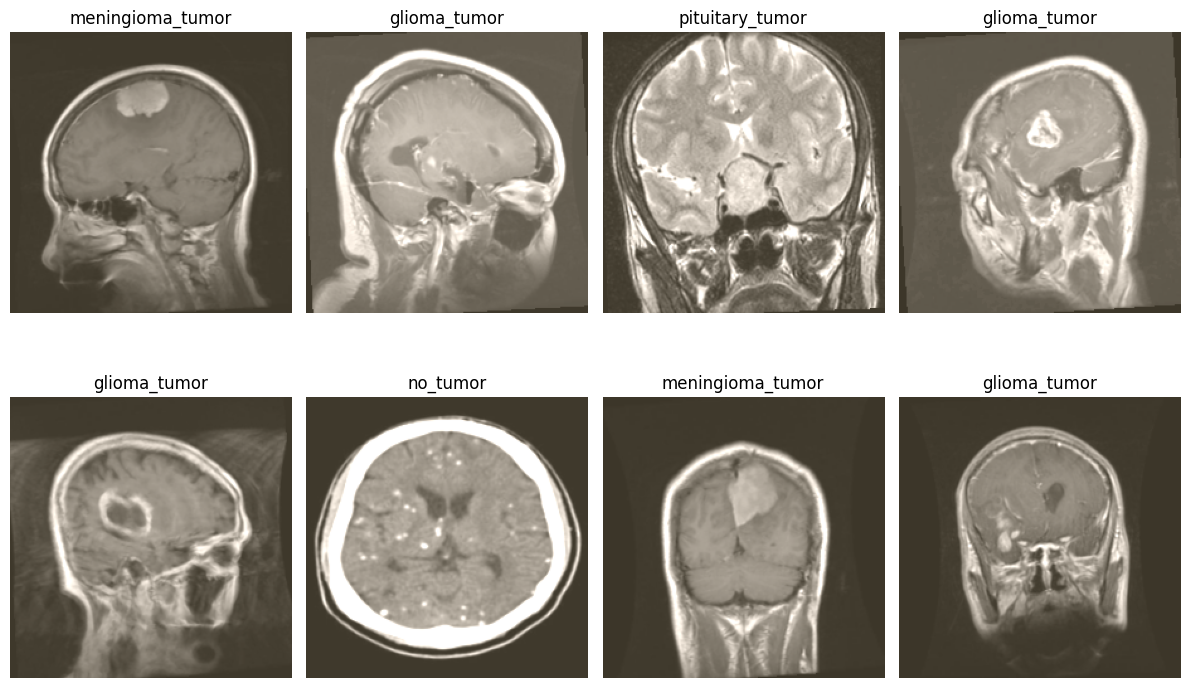

In [9]:
def denormalize(image):
    #Because normalization changes image values

    mean = torch.tensor(
        [0.485,0.456,0.406]
    )

    std = torch.tensor(
        [0.229,0.224,0.225]
    )

    image = image.permute(1,2,0)

    image = (
        image * std
        + mean
    )

    return image.clip(0,1)


#visualize
images, labels = next(iter(train_loader))


plt.figure(figsize=(12,8))


for i in range(8):

    plt.subplot(2,4,i+1)

    img = denormalize(images[i])

    plt.imshow(img)

    plt.title(
        train_dataset.classes[
            labels[i]
        ]
    )

    plt.axis("off")


plt.tight_layout()
plt.show()

## CHECK BATCH STATISTICS

In [10]:
print(
    "Batch mean:",
    images.mean().item()
)


print(
    "Batch std:",
    images.std().item()
)

Batch mean: 0.013271305710077286
Batch std: 1.0295525789260864


## CHECK DATALOADER SPEED

In [11]:
import time
start=time.time()

for batch in train_loader:
    pass
elapsed=time.time()-start

print(
    f"Loading time: {elapsed:.2f}s"
)

Loading time: 29.27s


## VERIFY BATCH ITERATION

In [12]:
for batch_idx, (images, labels) in enumerate(train_loader):

    print(
        f"""
Batch: {batch_idx}
Images: {images.shape}
Labels: {labels.shape}
"""
    )

    if batch_idx == 2:
        break


Batch: 0
Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])


Batch: 1
Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])


Batch: 2
Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])



## FINAL DATASET PIPELINE CHECK

In [13]:
assert images.shape[1:] == (
    3,
    config.image_size,
    config.image_size
)

assert labels.ndim == 1


print(
    "Data pipeline validation passed ✓"
)

Data pipeline validation passed ✓


# Conclusion

The PyTorch data pipeline was successfully validated.

Key findings:

- PyTorch version 2.8.0 is installed correctly.
- Apple Silicon MPS acceleration is available.
- Dataset transformations successfully convert images into tensors.
- Images are correctly formatted as:
    - Channels: 3
    - Height: 224
    - Width: 224

- DataLoader produces batches with the expected shape:
    - Batch size: 32
    - Tensor shape: (32, 3, 224, 224)

- Labels are correctly mapped to the four tumor classes.
- Normalization is applied successfully.
- The complete data pipeline passed validation.

The dataset is ready for model development and training.